Imports data from TN Julia simulation

In [1]:
%load_ext autoreload
%autoreload 2
#%matplotlib notebook

In [2]:
import numpy as np
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple
from matplotlib.collections import LineCollection
import matplotlib as mpl
import os
from math import comb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D, art3d
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.interpolate import interp1d
import json

In [3]:
plt.style.use("default")
plt.style.use("../../../config/unified_plots.mplstyle")
plt.rcParams['savefig.bbox'] = None
with open("../../../config/unified_plots.json", "r") as f:
    plot_args = json.load(f)
plot_opt_args = plot_args['optimization']

In [4]:
RASTERIZE = True
SAVE_FIGS = True
FULL_LINE_WIDTH_INCH = plot_args["fig_width_inches_full"]

In [5]:
if SAVE_FIGS:
    os.makedirs("../plots", exist_ok=True)

**Note:** The BO was originally performed as a minimization problem. The plotting, however, visualizes a maximization problem.

### Specifcation of the Majorana system (and Majorana basis)

In [6]:
n = 30 # number of qubits

In [7]:
# Load all data:
O = np.load(f"../data/coeffs_BO_{n}q.npy")
feature_vecs = np.load(f"../data/feat_vec_BO_{n}q.npy")
indices = np.load(f"../data/indices_BO_{n}q.npy")
outputs = -np.load(f"../data/outputs_BO_{n}q.npy")
ts = np.load(f"../data/t_list_BO_{n}q.npy")
# Load data form optiizatino, stored as npz file:
#np.savez(f"../dataopt_BO_{n}q.npz",
#         logged_ts=logged_ts, logged_obs=logged_obs, opt_t=opt_t, opt_obs=opt_obs, opt_idx=opt_idx,)
opt_res = np.load(f"../results/opt_BO_{n}q.npz")
bo_logged_ts = opt_res['bo_logged_ts']
bo_logged_obs = -opt_res['bo_logged_obs']
bo_opt_t = opt_res['bo_opt_t']
bo_opt_obs = -opt_res['bo_opt_obs']
bo_opt_idx = opt_res['bo_opt_idx']
bo_init = opt_res['bo_init']
#assert np.allclose(logged_ts.reshape(-1, 2)[opt_idx], opt_t)
#assert np.isclose(logged_obs[opt_idx], opt_obs)
bo_opt_after_n_steps = np.argmax(bo_logged_obs, axis=-1) + 1




SCIPY_METHODS = ["L-BFGS-B", "SLSQP", "COBYLA", "Nelder-Mead"]
scipy_opt_res = np.load(f"../results/opt_scipy_{n}q.npz")
scipy_logged_ts = {scipy_method: scipy_opt_res[f"{scipy_method}_logged_ts"] for scipy_method in SCIPY_METHODS}
scipy_logged_obs = {scipy_method: -scipy_opt_res[f"{scipy_method}_logged_obs"] for scipy_method in SCIPY_METHODS}
scipy_opt = {scipy_method: scipy_opt_res[f"{scipy_method}_opt"] for scipy_method in SCIPY_METHODS}
scipy_opt_val = {scipy_method: -scipy_opt_res[f"{scipy_method}_opt_val"] for scipy_method in SCIPY_METHODS}
scipy_opt_n_f_eval = {scipy_method: scipy_opt_res[f"{scipy_method}_opt_n_f_eval"] for scipy_method in SCIPY_METHODS}
scipy_n_f_evals = {scipy_method: scipy_opt_res[f"{scipy_method}_n_f_evals"] for scipy_method in SCIPY_METHODS}
scipy_init = {scipy_method: scipy_opt_res[f"{scipy_method}_init"] for scipy_method in SCIPY_METHODS}

SCIPY_METHODS.insert(0, "GD")
gd_opt_res = np.load(f"../results/opt_GD_{n}q.npz")
scipy_logged_ts["GD"] = gd_opt_res['gd_logged_ts']
scipy_logged_obs["GD"] = -gd_opt_res['gd_logged_obs']
scipy_opt_val["GD"] = -gd_opt_res['gd_opt_val']
scipy_opt_n_f_eval["GD"] = gd_opt_res['gd_n_f_eval']
scipy_n_f_evals["GD"] = np.full_like(scipy_logged_obs["GD"], -1, dtype=np.int64)
for i, opt_n_f_eval in enumerate(scipy_opt_n_f_eval["GD"]):
    scipy_n_f_evals["GD"][i, :opt_n_f_eval + 1] = np.arange(0, opt_n_f_eval + 1)
scipy_init["GD"] = gd_opt_res['gd_init']


print("Successfully loaded optimization results from file.")

Successfully loaded optimization results from file.


In [8]:
# Skip every second value:
skip = 1
ts = ts[::skip, ::skip, :]
feature_vecs = feature_vecs[1::skip, ::skip, :]
outputs = outputs[::skip, ::skip]

In [9]:
# Determine resolution of t grid:
t1_vals = np.sort(np.unique(ts[:, :, 0]))
t1_res = min(np.abs(np.diff(t1_vals)))
t2_vals = np.sort(np.unique(ts[:, :, 1]))
t2_res = min(np.abs(np.diff(t2_vals)))
print(f"t1 resolution: {t1_res}, t2 resolution: {t2_res}")
print(f"range / num:", t1_vals[-1] - t1_vals[0], len(t1_vals), t2_vals[-1] - t2_vals[0], len(t2_vals))

t1 resolution: 0.06122448979591821, t2 resolution: 0.06122448979591821
range / num: 3.0 50 3.0 50


In [10]:
# Interpolate more finely:
import scipy.ndimage
INTERPOL_FACTOR = 2.
ts_fine = np.dstack((scipy.ndimage.zoom(ts[:,:, 0], zoom=INTERPOL_FACTOR, order=1, mode='nearest'),
                     scipy.ndimage.zoom(ts[:,:, 1], zoom=INTERPOL_FACTOR, order=1, mode='nearest')))
outputs_fine = scipy.ndimage.zoom(outputs, zoom=INTERPOL_FACTOR, mode='nearest')

In [11]:
# remove first all zero outputs:
ts = ts[1::, ...]
outputs = outputs[1::, ...]
ts_fine = ts_fine[1::, ...]
outputs_fine = outputs_fine[1::, ...]

In [12]:
# Realize multi-dimensional ts via flattening and running the kernel/GP in index mode:
ts_flattened = ts.reshape(-1, 2)  # Flatten ts for easier indexing
ts_flat_indices = np.arange(ts_flattened.shape[0])  # Create indices for flattened ts
outputs_flattened = outputs.flatten()  # Flatten outputs for easier indexing
feature_vecs_flattened = feature_vecs.reshape(-1, feature_vecs.shape[-1])  # Flatten feature vectors

In [13]:
# Infer the majorana system:
d = 2*n
# determine number of majoranas in the observable
for m in range(d):
    if comb(d, m) == feature_vecs.shape[-1]:
        break
print(f"Module B_{m}")
num_data_points = len(outputs)
n_params = ts.shape[-1] if ts.ndim > 1 else 1

Module B_1


In [14]:
#params = {'mathtext.default': 'regular' }
#plt.rcParams.update(params)

In [15]:
# Assume ts (n, m, 2) and outputs (n, m) are defined
X = ts_fine[:, :, 0]
Y = ts_fine[:, :, 1]
Z = outputs_fine

# Global minimum
opt_idx = np.unravel_index(np.argmax(outputs), outputs.shape)
opt_t = ts[opt_idx]
opt_val = outputs[opt_idx]

landscape_cmap = "YlGnBu"  # Color map for the cost landscape

global_min_color = plt.colormaps.get_cmap(landscape_cmap)([-1, 1.])[-1]  # Color for the global minimum (lowest color)

# BO trajectory plotting parameters:
bo_cmap = plt.colormaps.get_cmap("spring_r")
#bo_colors = bo_cmap(np.linspace(0, 1,opt_after_n_steps + 1))[1:]
bo_marker_style = 's'
bo_s = 10

# scipy (and GD) trajectory plotting parameters:
scipy_colors = ['blue', 'orange', 'red', 'green', 'purple']
scipy_cmaps = [mpl.colors.LinearSegmentedColormap.from_list(f"white2{c}", [(0.0, 'white'), (1.0, c)]) for c in scipy_colors]
scipy_markers = ['o', '^', 'v', 'P', 'X', 'D',]
scipy_colors = dict(zip(SCIPY_METHODS, scipy_colors))
scipy_cmaps = dict(zip(SCIPY_METHODS, scipy_cmaps))
scipy_markers = dict(zip(SCIPY_METHODS, scipy_markers))



In [16]:
def fix_label(label):
    #label = label.replace("Nelder-Mead", "Simplex")
    #label = label.replace("L-BFGS-B", "L-BFGS")
    label = label.replace("BO", "QGP-BO")
    label = label.replace("GD", "Grad Desc")
    return label

/var/folders/7_/vz1nj3hx5psd4x1v80v8lrch0000gn/T/ipykernel_70057/1426159026.py:156: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.savefig(f"../plots/BO_{n}q_landscape.pdf", transparent=True,


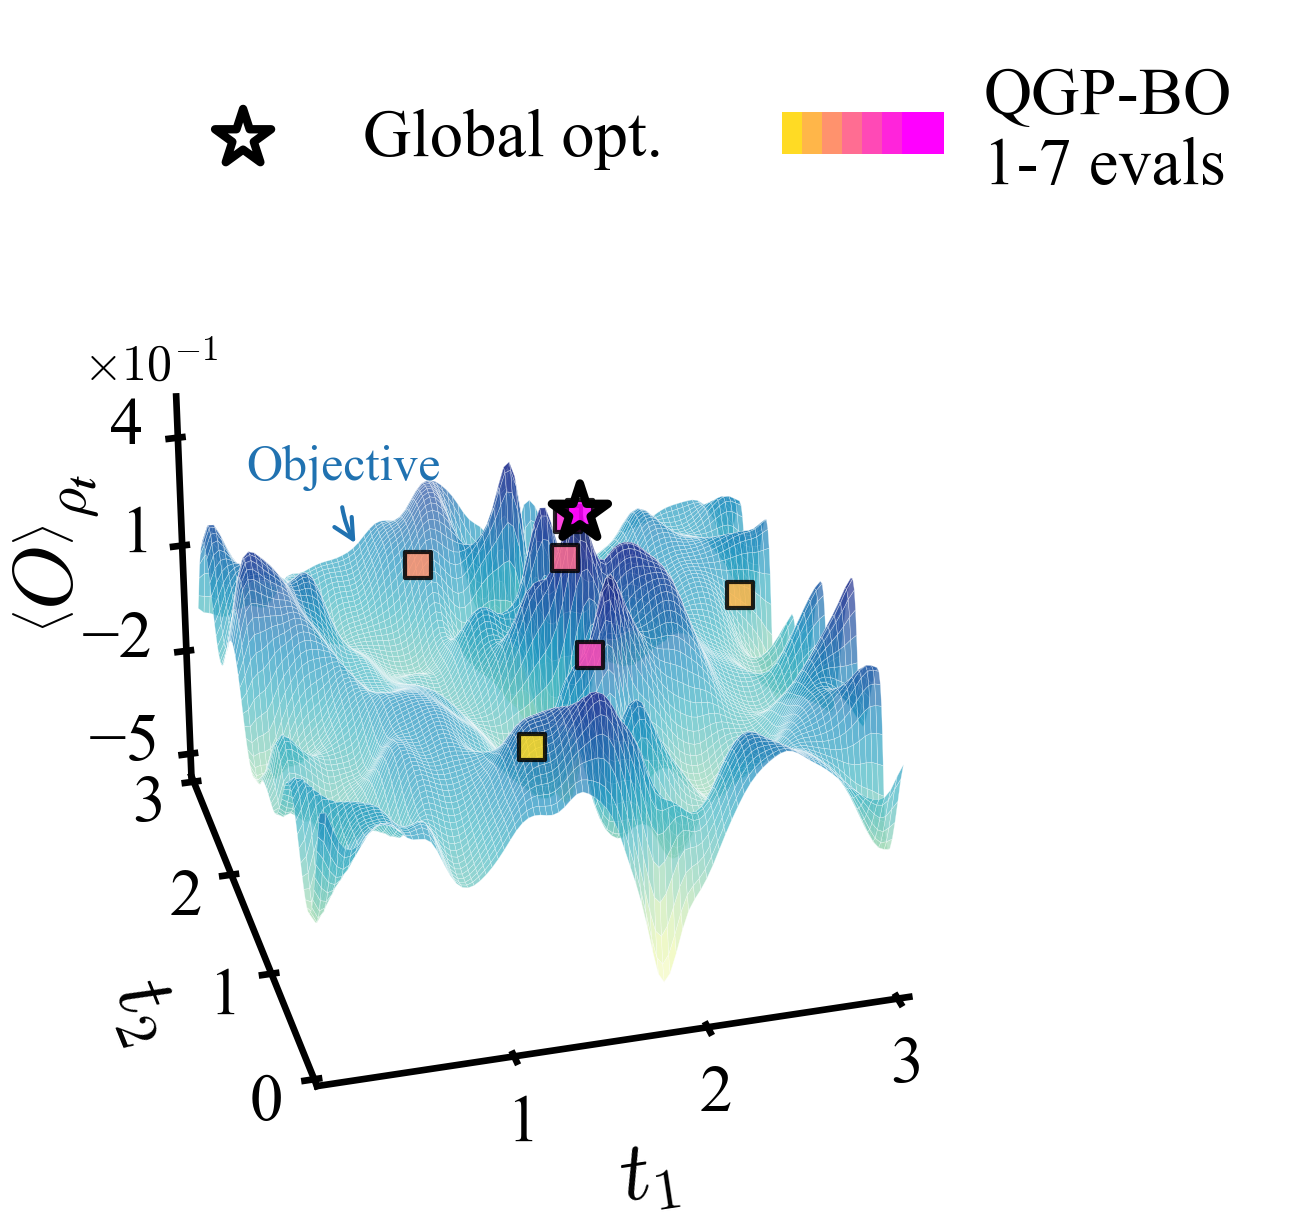

In [17]:
 def plot_cost_landscape_3d(ax, arrow_direction_threshold=None):
    assert ax.name == '3d', "ax must be a 3D axis"
    #cmap="coolwarm"
    #cmap="YlGnBu_r"
    ax.plot_surface(X[1:, :], Y[1:, :], Z[1:, :], cmap=landscape_cmap, lw=0.5, alpha=0.7, antialiased=True, zorder=0,
                    linewidth=0.05, edgecolor='white', rstride=1, cstride=1, rasterized=RASTERIZE)

    if arrow_direction_threshold is None:
        arrow_direction_threshold = np.mean(outputs)

    label_pad = -10
    tick_pad = -5
    tick_pad_z = -5

    # BO optimization trajectory (pick single run):
    bo_idx_pick = 0
    logged_ts = bo_logged_ts[bo_idx_pick]
    logged_obs = bo_logged_obs[bo_idx_pick]
    opt_after_n_steps = bo_opt_after_n_steps[bo_idx_pick]
    bo_colors = bo_cmap(np.linspace(0, 1, opt_after_n_steps + 1))[1:]  # Exclude first color (initial guess)
    # use scatter plot (no connecting lines) and color gradient over time:
    logged_ts_flat = logged_ts.reshape(-1, 2)  # Flatten for scatter plot
    logged_obs_flat = logged_obs.flatten()  # Flatten outputs for scatter plot
    # Plot the optimization trajectory
    for i in range(opt_after_n_steps):
    #     x, y = logged_ts_flat[i]
    #     dz = 0.15
    #     pad = 0.2
    #     z = logged_obs_flat[i] - dz - pad
    #     if logged_obs_flat[i] > arrow_direction_threshold:
    #         dz = -dz
    #         z = logged_obs_flat[i] + dz + 0.7
    #     ax.plot([x, x], [y, y], [z + dz*1.1  , logged_obs_flat[i]], color=bo_colors[i], linestyle='dashed', linewidth=0.75, alpha=0.7)
    #     ax.quiver(x, y, z, 0, 0, + dz, color=bo_colors[i], arrow_length_ratio=0.5, linewidth=0.75, alpha=1, )


        ax.scatter(logged_ts_flat[i, 0], logged_ts_flat[i, 1], logged_obs_flat[i], marker=bo_marker_style, facecolors=bo_colors[i], s=bo_s, alpha=0.85, **plot_opt_args['scatter'])

    # label landscape
    text_color = plt.get_cmap(landscape_cmap)(0.7)
    # ax.text2D(0.76, 0.24, "Objective",
    #           transform=ax.transAxes,
    #           color=text_color,
    #           fontsize=6,
    #           rotation=70,
    #           #fontweight='bold',
    #           ha='right',   # Right-align so the text grows inward from the corner
    #           va='bottom',  # Bottom-align so it sits neatly on the edge
    #           zorder=100)
    ax.annotate("Objective",
                xy=(0.32, 0.67),          # Where the arrow POINTS (try aiming for the middle/bottom of the surface)
                xytext=(0.2, 0.78),     # Where the TEXT sits
                xycoords='axes fraction',
                textcoords='axes fraction',
                color=text_color,
                fontsize=6,
                ha='left',
                va='top',
                zorder=100,
                arrowprops=dict(
                    arrowstyle="->",      # The style of the arrow head
                    color=text_color,     # Match the arrow color to the text
                    lw=0.5,               # Line width of the arrow
                    connectionstyle="arc3,rad=0.2", # Optional: gives the arrow a slight, elegant curve!
                    shrinkA=0, shrinkB=0.5  # Adds a tiny bit of padding so the arrow doesn't touch the text
                ))

    # Mark the global minimum
    global_marker_style = '*'
    global_opt_3d_scatter = ax.scatter(opt_t[0], opt_t[1], opt_val, marker=global_marker_style, facecolors='none', s=50, label=f"Global opt.", linewidths=1, edgecolors='black',zorder=500)

    # Axis labels
    ax.set_xlabel(r'$t_1$', labelpad=label_pad)
    ax.set_ylabel(r'$t_2$', labelpad=label_pad)
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel(r'$\left\langle {O} \right\rangle_{\rho_{\boldsymbol{t}}}$', rotation=90, labelpad=label_pad)

    ax.tick_params(axis='x', pad=tick_pad)
    ax.tick_params(axis='y', pad=tick_pad)
    ax.tick_params(axis='z', pad=tick_pad_z)

    ax.set_zticks(np.around(np.linspace(round(np.min(Z), 1), round(np.max(Z),1), 4), decimals=1))
    ax.ticklabel_format(axis='z', style='sci', scilimits=(-1, -1), useMathText=True)
    ax.zaxis.get_offset_text().set_visible(False)
    ax.text2D(0.025, 0.85, r'$\times 10^{-1}$', transform=ax.transAxes, fontsize=6)


    for label in ax.get_zticklabels():
        label.set_horizontalalignment('right')
        label.set_verticalalignment('center')
    for label in ax.get_yticklabels():
        label.set_horizontalalignment('right')  # Try 'right' or 'center' depending on your azim!
        label.set_verticalalignment('center')
    y_label = ax.yaxis.get_label()
    y_label.set_horizontalalignment('left') # Try 'left' or 'right' if 'center' doesn't snap it into place
    y_label.set_verticalalignment('center')

    scatter_handles = tuple([
    mpl.lines.Line2D([0], [0], marker=bo_marker_style, color='w', markerfacecolor=bo_colors[i], linestyle='None', markeredgewidth=0, alpha=1,
                     markersize=5)
    for i in range(opt_after_n_steps)
])

    # Add the custom legend handle to the existing legend entries
    handles, labels = ax.get_legend_handles_labels()
    handles.insert(1, scatter_handles)
    labels.insert(1, f'QGP-BO\n1-{opt_after_n_steps} evals')
    # Legend
    ax.legend(
        loc='upper right',
        bbox_to_anchor=(1, 1),
        bbox_transform=fig.transFigure,
        borderaxespad=0.0,
        borderpad=0.1,
              ncol=2,
              frameon=False,
              handles=handles, labels=labels,
              handler_map={tuple: HandlerTuple(ndivide=None, pad=0.1)})

    ax.grid(False)
    # Remove 3D panes (background walls)
    ax.xaxis.pane.set_visible(False)
    ax.yaxis.pane.set_visible(False)
    ax.zaxis.pane.set_visible(False)
    # set limits for z
    ax.set_zlim(np.min(Z) - 0.05, np.max(Z) + 0.05)  # Add some padding to the z-axis limits


    # Force the X and Y axes to only display integer ticks
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Tweak view angle for clarity (optional)
    #ax.view_init(elev=30, azim=70)
    ax.view_init(elev=30, azim=75+180)

W = plot_args['fig_width_inches_full']
fig = plt.figure(figsize=(W * 0.33, 2.), dpi=600)

# left plot
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)  # span accross all rows in first column
plot_cost_landscape_3d(ax=ax, arrow_direction_threshold=-np.inf)
ax3d = ax
#ax3d.set_box_aspect(aspect = (1.2,1.2,1))


ax3d.set_facecolor("none")

plt.rcParams['savefig.bbox'] = None

fig.subplots_adjust(left=0.0, right=1.05, bottom=0.0, top=1.1)
ax3d.margins(x=0, y=0, z=0)

# No tight layout!
if SAVE_FIGS:
    plt.savefig(f"../plots/BO_{n}q_landscape.pdf", transparent=True,
                bbox_inches=None,
                #bbox_inches='tight',
                #pad_inches=0.0,
                dpi=600)  # For paper
plt.show()

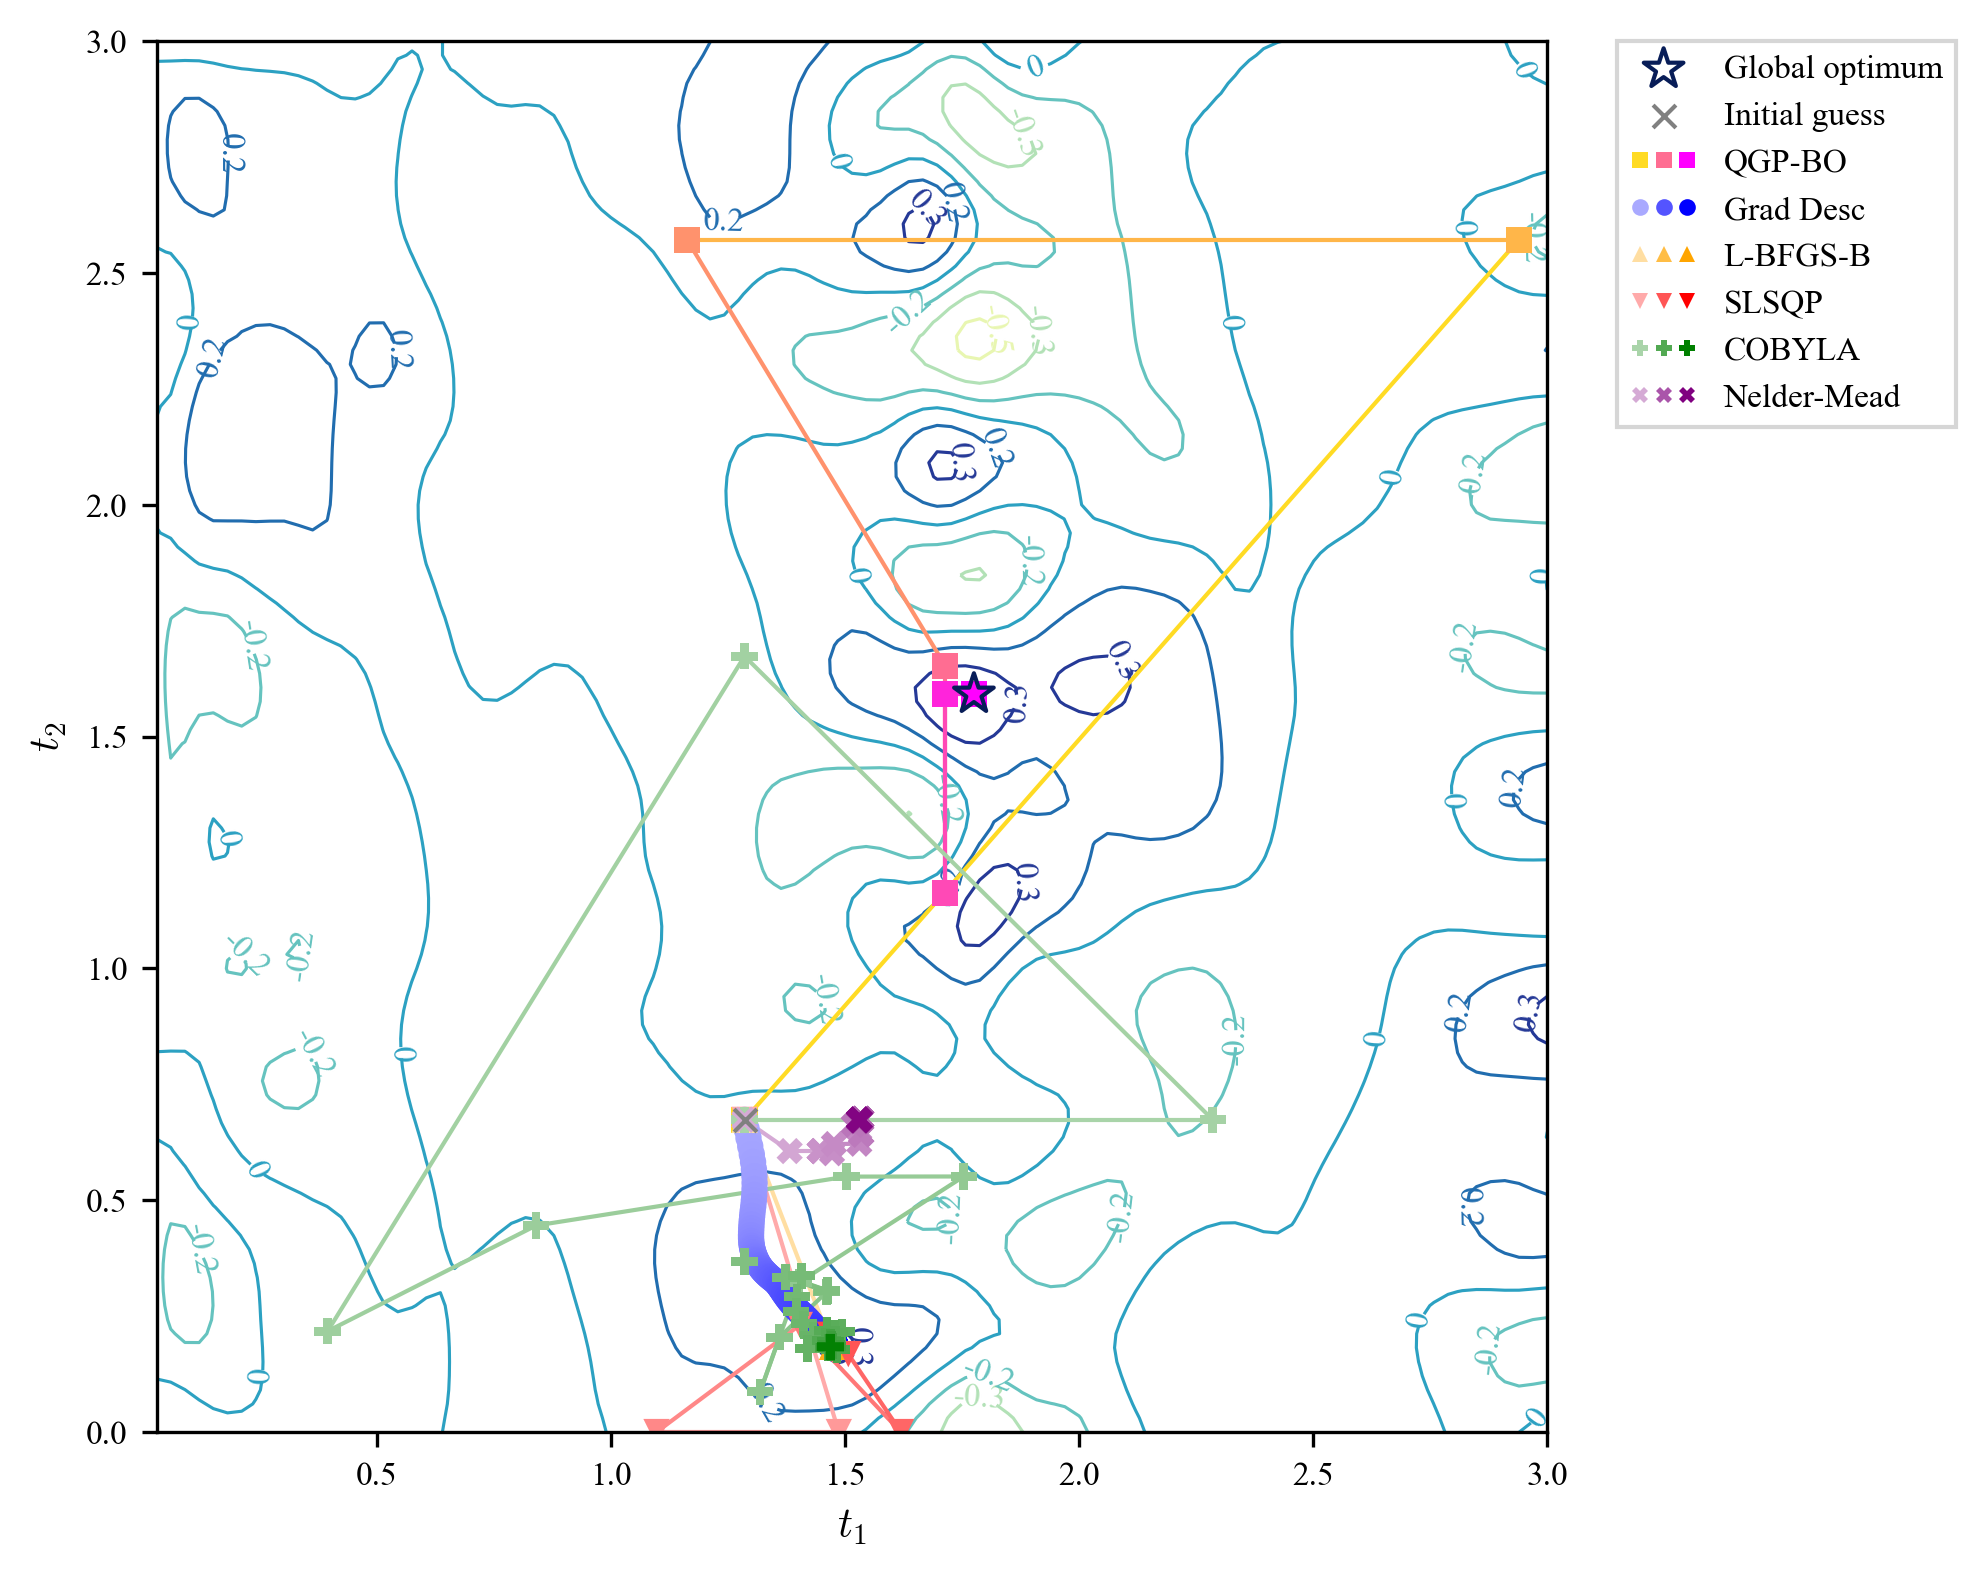

In [18]:
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap

def plot_cost_contour_traj_2d(ax):
    N_TRAJS = [0]
    scatter_size = 40
    linewidth = 1

    assert ax.name != '3d', "ax must not be a 3D axis"
    cont = ax.contour(X, Y, Z, levels=None, cmap=landscape_cmap, linestyles="solid", zorder=-20, linewidths=0.75)
    def contour_label_fmt(val):
        return f" {int(val)} " if float(val).is_integer() else f"{val:.1f}"
    plt.clabel(cont, inline=True, inline_spacing=2, fontsize=8, fmt=contour_label_fmt)

    # Mark the global minimum
    global_marker_style = '*'
    global_opt_3d_scatter = ax.scatter(opt_t[0], opt_t[1], marker=global_marker_style, edgecolors=global_min_color, facecolors='none', s=100,
                                       label="Global optimum",
                                       zorder=10)
    # Initial guess:
    ax.scatter(*scipy_init['GD'][0], marker='x', color='gray', s=30, label='Initial guess',
               zorder=10)


    # BO optimization trajectory:
    # use scatter plot (no connecting lines) and color gradient over time:
    for i, bo_i in enumerate(N_TRAJS):
        logged_ts, logged_obs, opt_after_n_steps = list(zip(bo_logged_ts, bo_logged_obs, bo_opt_after_n_steps))[bo_i]
        logged_ts_flat = logged_ts.reshape(-1, 2)  # Flatten for scatter plot
        logged_obs_flat = logged_obs.flatten()  # Flatten outputs for scatter plot
        bo_colors = bo_cmap(np.linspace(0, 1, opt_after_n_steps + 1))[1:]  # Exclude first color (initial guess)

        # Plot the optimization trajectory on 2d contour plot:
        pts = logged_ts_flat[:opt_after_n_steps]
        # Build line segments between successive points
        segments = np.stack([pts[:-1], pts[1:]], axis=1)  # shape (n_segments, 2, 2)

        # Use a ListedColormap to ensure exact match to scatter colors
        cmap = ListedColormap(bo_colors)

        lc = LineCollection(
            segments,
            colors=cmap(range(len(segments))),  # one color per segment
            linewidth=linewidth,
            zorder=-10,
            rasterized=RASTERIZE  ### ADDED RASTERIZED ###
        )
        ax.add_collection(lc)
        ax.scatter(logged_ts_flat[:opt_after_n_steps, 0], logged_ts_flat[:opt_after_n_steps, 1], marker=bo_marker_style, edgecolors='none', facecolors=bo_colors, s=scatter_size, alpha=1, 
                   rasterized=RASTERIZE) ### ADDED RASTERIZED ###


        if bo_i == 0:
            scatter_handles = tuple([
            mpl.lines.Line2D([0], [0], marker=bo_marker_style, color='w', markerfacecolor=bo_colors[i], linestyle='None', markeredgewidth=0, alpha=1)
            for i in [0, opt_after_n_steps // 2, opt_after_n_steps - 1]
    ])

    # Add the custom legend handle to the existing legend entries
    handles, labels = ax.get_legend_handles_labels()
    handles.append(scatter_handles)
    labels.append(fix_label('BO'))

    # Scipy (and GD) optimization trajectories:
    for scipy_method in SCIPY_METHODS:
        scipy_marker = scipy_markers[scipy_method]
        for i, gd_i in enumerate(N_TRAJS):
            xs, ys = list(zip(scipy_logged_ts[scipy_method], scipy_logged_obs[scipy_method]))[gd_i]
            
            # cap at maximum value (flipped for maximization):
            gd_max_idx = np.argmax(ys) ### CHANGED TO ARGMAX ###
            xs = xs[:gd_max_idx + 1]
            ys = ys[:gd_max_idx + 1]

            scipy_c = scipy_cmaps[scipy_method](np.linspace(0, 1, round((3/2)*len(ys))))[-len(ys):]  # skip first half of the colors
            
            ### REPLACED SINGLE LINE PLOT WITH LINECOLLECTION ###
            pts = xs
            segments = np.stack([pts[:-1], pts[1:]], axis=1)
            cmap = ListedColormap(scipy_c)
            
            lc = LineCollection(
                segments,
                colors=cmap(range(len(segments))),
                linewidth=linewidth,
                zorder=-10,
                rasterized=RASTERIZE ### ADDED RASTERIZED ###
            )
            ax.add_collection(lc)
            
            ax.scatter(xs[:, 0], xs[:, 1], marker=scipy_marker, edgecolors='none', facecolors=scipy_c, s=scatter_size, alpha=1, 
                       rasterized=RASTERIZE) ### ADDED RASTERIZED ###
            
            # set limits:
            ax.set_xlim(np.min(X), np.max(X))
            ax.set_ylim(np.min(Y), np.max(Y))

            if i == 0:
                gd_scatter_handles = tuple([
                    mpl.lines.Line2D([0], [0], marker=scipy_marker, color='w', markerfacecolor=scipy_c[i], linestyle='none', markeredgewidth=0, alpha=1)
                    for i in [0, len(scipy_c) // 2, len(scipy_c) - 1]
                ])

                handles.append(gd_scatter_handles)
                label = fix_label(scipy_method)
                labels.append(label)

    # Axis labels
    ax.set_xlabel(r'$t_1$')
    ax.set_ylabel(r'$t_2$')

    ax.set_box_aspect(1)

    # Legend
    ax.legend(loc='upper left',         
              bbox_to_anchor=(1.05, 1.0),
              borderaxespad=0,
              facecolor='white',
              handles=handles, labels=labels,
              handler_map={tuple: HandlerTuple(ndivide=None, pad=0.1)})

    # Copy the exact tick locations from X to Y
    ax.set_yticks(ax.get_xticks())

    return ax, handles, labels

fig = plt.figure(figsize=(FULL_LINE_WIDTH_INCH, 20))  # 6, 4
ax = fig.add_subplot(111)
plot_cost_contour_traj_2d(ax=ax)
plt.tight_layout()
#if SAVE_FIGS:
#    plt.savefig(f"../plots/BO_{n}q_bench_traj.pdf", transparent=True, dpi=300)  # For paper
plt.show()

In [19]:
rand_res = np.load(f"../results/opt_rand_{n}q.npz")
rand_n_evals = rand_res['rand_n_evals']
rand_opt_diffs = rand_res['rand_opt_diffs']
n_samples_per_eval = rand_res['n_samples_per_eval']
max_n_evals = len('rand_n_evals')

BO 7
BO 12
BO 6
BO 8
BO 12
BO 9
BO 8
BO 9
BO 9
BO 16
BO 14
BO 9
BO 8
BO 12
BO 10
BO 15
BO 4
BO 9
BO 10
BO 16
BO 9
BO 7
BO 16
BO 11
BO 16
BO 9
BO 8
BO 13
BO 8
BO 9
BO 12
BO 12
BO 7
BO 15
BO 10
BO 11
BO 8
BO 13
BO 15
BO 7
BO 11
BO 13
BO 12
BO 11
BO 12
BO 11
BO 14
BO 10
BO 10
BO 13
BO 7
BO 14
BO 13
BO 12
BO 12
BO 14
BO 12
BO 15
BO 12
BO 11
BO 3
BO 11
BO 11
BO 10
BO 14
BO 10
BO 8
BO 12
BO 13
BO 13
BO 15
BO 8
BO 8
BO 13
BO 8
BO 10
BO 6
BO 15
BO 11
BO 12
BO 11
BO 16
BO 7
BO 11
BO 15
BO 11
BO 11
BO 13
BO 13
BO 8
BO 12
BO 11
BO 9
BO 10
BO 3
BO 7
BO 11
BO 6
BO 9
BO 8
(100, 10001)
[ 83  17   0  79  89  10  19   5   8  25  37  42 253   0   0  86   4 125
  78 142  78  52  29  13  88 250  21  26 565  49 102  72  99  11   2  13
 220 210   8 152   7 674  14   0 115   0   5  66  34  24  86 119  12  34
  24 192 114   7  52  52   7  10 571  11  28  84  13   2  89 168  23  29
 209 196 443   2  15   8 103 323  57  93  41 132  52  14 462  23 460  23
  26  17 142  66 133  27 123   9 140  27]
GD better than 

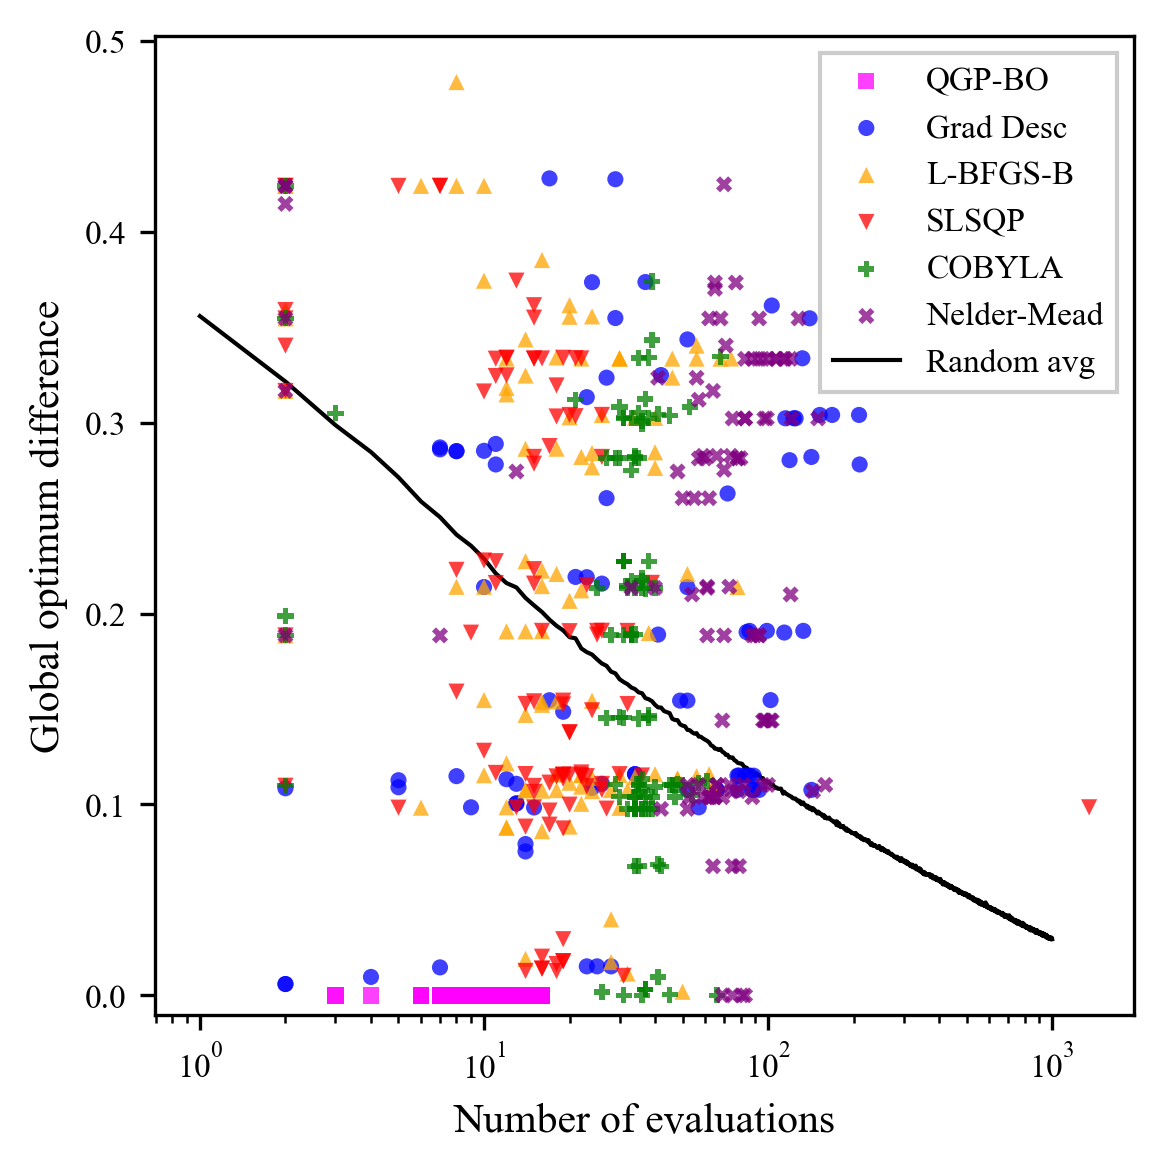

In [20]:
def plot_num_evals_vs_opt_diff(ax):
    scatter_size = 15
    scatter_alpha = 0.75
    #                - [ ] Scatter plot with #func evals vs. f_opt value difference
#                    - [ ] Show something like average func value difference
#                    - [ ] Potentially needs log axis for # evals
    assert ax.name != '3d', "ax must not be a 3D axis"
    # Calculate the difference between the optimal value and the observed values
    for bo_i in range(len(bo_logged_obs)):
        logged_obs = bo_logged_obs[bo_i]
        opt_obs = bo_opt_obs[bo_i]
        bo_colors = bo_cmap(np.linspace(0, 1, bo_opt_after_n_steps[bo_i] + 1))[1:]  # Exclude first color (initial guess)
        opt_after_n_steps = bo_opt_after_n_steps[bo_i]
        opt_diff = np.abs(np.max(outputs) - opt_obs)
        print("BO", opt_after_n_steps)
        # Plot the number of evaluations vs. the difference from the optimal value
        ax.scatter([opt_after_n_steps], [opt_diff], marker=bo_marker_style,
                    edgecolors='none', facecolors=bo_colors[-1], s=scatter_size, alpha=scatter_alpha, zorder=+20, label=fix_label("BO") if bo_i == 0 else None,)

    avg_rand_opt_diffs = np.array([np.mean(diffs) for diffs in rand_opt_diffs])

    # scipy results:
    for scipy_method_i, scipy_method in enumerate(SCIPY_METHODS):
        # Calculate the difference from the optimal value
        #scipy_opt_diff = np.abs(scipy_opt_val[scipy_method] - np.min(outputs))
        best_scipy_idx = np.nanargmax(scipy_logged_obs[scipy_method], axis=-1)
        scipy_bests = np.array([scipy_logged_obs[scipy_method][run_i, idx] for run_i, idx in enumerate(best_scipy_idx)])
        scipy_opt_diff = np.abs(scipy_bests - np.max(outputs))
        # Get the number of evaluations
        #n_evals = scipy_n_f_eval[scipy_method]
        print(scipy_n_f_evals[scipy_method].shape)
        n_evals = np.array([scipy_n_f_evals[scipy_method][run_i, idx] for run_i, idx in enumerate(best_scipy_idx)])
        assert np.all(n_evals != -1)
        print(n_evals)
        #n_evals = min_scipy_idx + 1  # Get the number of evaluations for the minimum difference
        # Plot the results
        ax.scatter([n_evals], [scipy_opt_diff], marker=scipy_markers[scipy_method],
                   edgecolors='none', facecolors=scipy_colors[scipy_method],
                   s=scatter_size, alpha=scatter_alpha, label=fix_label(scipy_method), )
        # Add a label to the best scatter point (min_scipy_idx):
       # min_dist_init = np.linalg.norm(scipy_init[scipy_method][min_scipy_idx] - opt_t)
        #ax.text(n_evals[min_scipy_idx], scipy_opt_diff[min_scipy_idx], f"{min_dist_init}",
        #        fontsize=10, ha='left', va='bottom', color=scipy_color)

        better_than_random = 0
        for opt_diff, n_eval in zip(scipy_opt_diff, n_evals):
            if n_eval - 1 >= len(avg_rand_opt_diffs):
                print(f"Warning: n_eval {n_eval} exceeds precomputed random evals {len(avg_rand_opt_diffs)}")
                n_eval = len(avg_rand_opt_diffs)
            if opt_diff < avg_rand_opt_diffs[n_eval - 1]:
                better_than_random += 1
        print(f"{scipy_method} better than random sampling for {better_than_random} out of {len(scipy_opt_diff)} evaluations ({100*better_than_random / len(scipy_opt_diff)}%).")



    # Calculate the average difference for this number of evaluations
    #std_rand_opt_diffs = np.array([np.std(diffs) for diffs in rand_opt_diffs])
    #ax.scatter(rand_n_evals, avg_rand_opt_diffs, marker='x',
    #           edgecolors='none', facecolor='gray',
    #           s=10, alpha=0.5, zorder=-5, label='Random sampling')
    ax.plot(rand_n_evals, avg_rand_opt_diffs, color='black', linestyle='-', linewidth=1, zorder=-5, label='Random avg')
    #cis = 1.96 * std_rand_opt_diffs / np.sqrt(n_samples_per_eval)  # 95% confidence interval
    #ax.fill_between(rand_n_evals, avg_rand_opt_diffs - cis, avg_rand_opt_diffs + cis,
    #                color='gray', alpha=0.2, zorder=-5)


    # Plot horizontal line at average difference
    #avg_diff = np.mean(np.abs(logged_obs - opt_obs))
    #ax.axhline(avg_diff, color='gray', linestyle='--', label=f'Average diff: {avg_diff:.2f}', zorder=-10)

    # Axis labels
    ax.set_xlabel('Number of evaluations')
    ax.set_ylabel(r'Global optimum difference')
    #ax.set_yscale('log')  # Use logarithmic scale for better visibility
    ax.set_xscale('log')  # Use logarithmic scale for better visibility
    ax.set_ylim(-0.01, None)

    ax.set_box_aspect(1)

    ax.legend(facecolor='white', framealpha=1)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
plot_num_evals_vs_opt_diff(ax=ax)
plt.tight_layout()
#if SAVE_FIGS:
#    plt.savefig(f"../plots/BO_{n}q_bench_num_evals.pdf", transparent=True, dpi=300)  # For paper
plt.show()

In [21]:
sn = "GD"
best_scipy_idx = np.nanargmin(scipy_logged_obs[sn], axis=-1)
print([[run_i,idx] for run_i, idx in enumerate(best_scipy_idx)])
print(scipy_logged_obs[sn][0][:best_scipy_idx[0]+1], scipy_logged_obs[sn][0][best_scipy_idx[0]-1])
#[scipy_logged_obs[sn][run_i][idx] for run_i, idx in enumerate(min_scipy_idx)]
[scipy_n_f_evals[sn][run_i, idx] for run_i, idx in enumerate(best_scipy_idx)]

[[0, 0], [1, 0], [2, 12], [3, 0], [4, 0], [5, 0], [6, 0], [7, 0], [8, 0], [9, 0], [10, 0], [11, 0], [12, 0], [13, 38], [14, 168], [15, 0], [16, 0], [17, 0], [18, 0], [19, 0], [20, 0], [21, 0], [22, 0], [23, 0], [24, 0], [25, 0], [26, 0], [27, 0], [28, 0], [29, 0], [30, 23], [31, 0], [32, 0], [33, 0], [34, 0], [35, 0], [36, 0], [37, 5], [38, 0], [39, 0], [40, 0], [41, 5], [42, 0], [43, 0], [44, 0], [45, 0], [46, 0], [47, 0], [48, 0], [49, 0], [50, 0], [51, 0], [52, 0], [53, 0], [54, 0], [55, 0], [56, 0], [57, 0], [58, 0], [59, 0], [60, 0], [61, 0], [62, 0], [63, 0], [64, 0], [65, 0], [66, 0], [67, 1], [68, 0], [69, 0], [70, 2], [71, 0], [72, 0], [73, 1], [74, 0], [75, 0], [76, 0], [77, 0], [78, 0], [79, 2], [80, 0], [81, 0], [82, 0], [83, 0], [84, 0], [85, 0], [86, 0], [87, 0], [88, 0], [89, 0], [90, 0], [91, 0], [92, 0], [93, 0], [94, 0], [95, 0], [96, 0], [97, 0], [98, 0], [99, 0]]
[0.05565219] nan


[0,
 0,
 12,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 38,
 168,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 23,
 0,
 0,
 0,
 0,
 0,
 0,
 5,
 0,
 0,
 0,
 5,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 2,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 2,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

BO 7
BO 12
BO 6
BO 8
BO 12
BO 9
BO 8
BO 9
BO 9
BO 16
BO 14
BO 9
BO 8
BO 12
BO 10
BO 15
BO 4
BO 9
BO 10
BO 16
BO 9
BO 7
BO 16
BO 11
BO 16
BO 9
BO 8
BO 13
BO 8
BO 9
BO 12
BO 12
BO 7
BO 15
BO 10
BO 11
BO 8
BO 13
BO 15
BO 7
BO 11
BO 13
BO 12
BO 11
BO 12
BO 11
BO 14
BO 10
BO 10
BO 13
BO 7
BO 14
BO 13
BO 12
BO 12
BO 14
BO 12
BO 15
BO 12
BO 11
BO 3
BO 11
BO 11
BO 10
BO 14
BO 10
BO 8
BO 12
BO 13
BO 13
BO 15
BO 8
BO 8
BO 13
BO 8
BO 10
BO 6
BO 15
BO 11
BO 12
BO 11
BO 16
BO 7
BO 11
BO 15
BO 11
BO 11
BO 13
BO 13
BO 8
BO 12
BO 11
BO 9
BO 10
BO 3
BO 7
BO 11
BO 6
BO 9
BO 8
(100, 10001)
[ 83  17   0  79  89  10  19   5   8  25  37  42 253   0   0  86   4 125
  78 142  78  52  29  13  88 250  21  26 565  49 102  72  99  11   2  13
 220 210   8 152   7 674  14   0 115   0   5  66  34  24  86 119  12  34
  24 192 114   7  52  52   7  10 571  11  28  84  13   2  89 168  23  29
 209 196 443   2  15   8 103 323  57  93  41 132  52  14 462  23 460  23
  26  17 142  66 133  27 123   9 140  27]
GD better than 

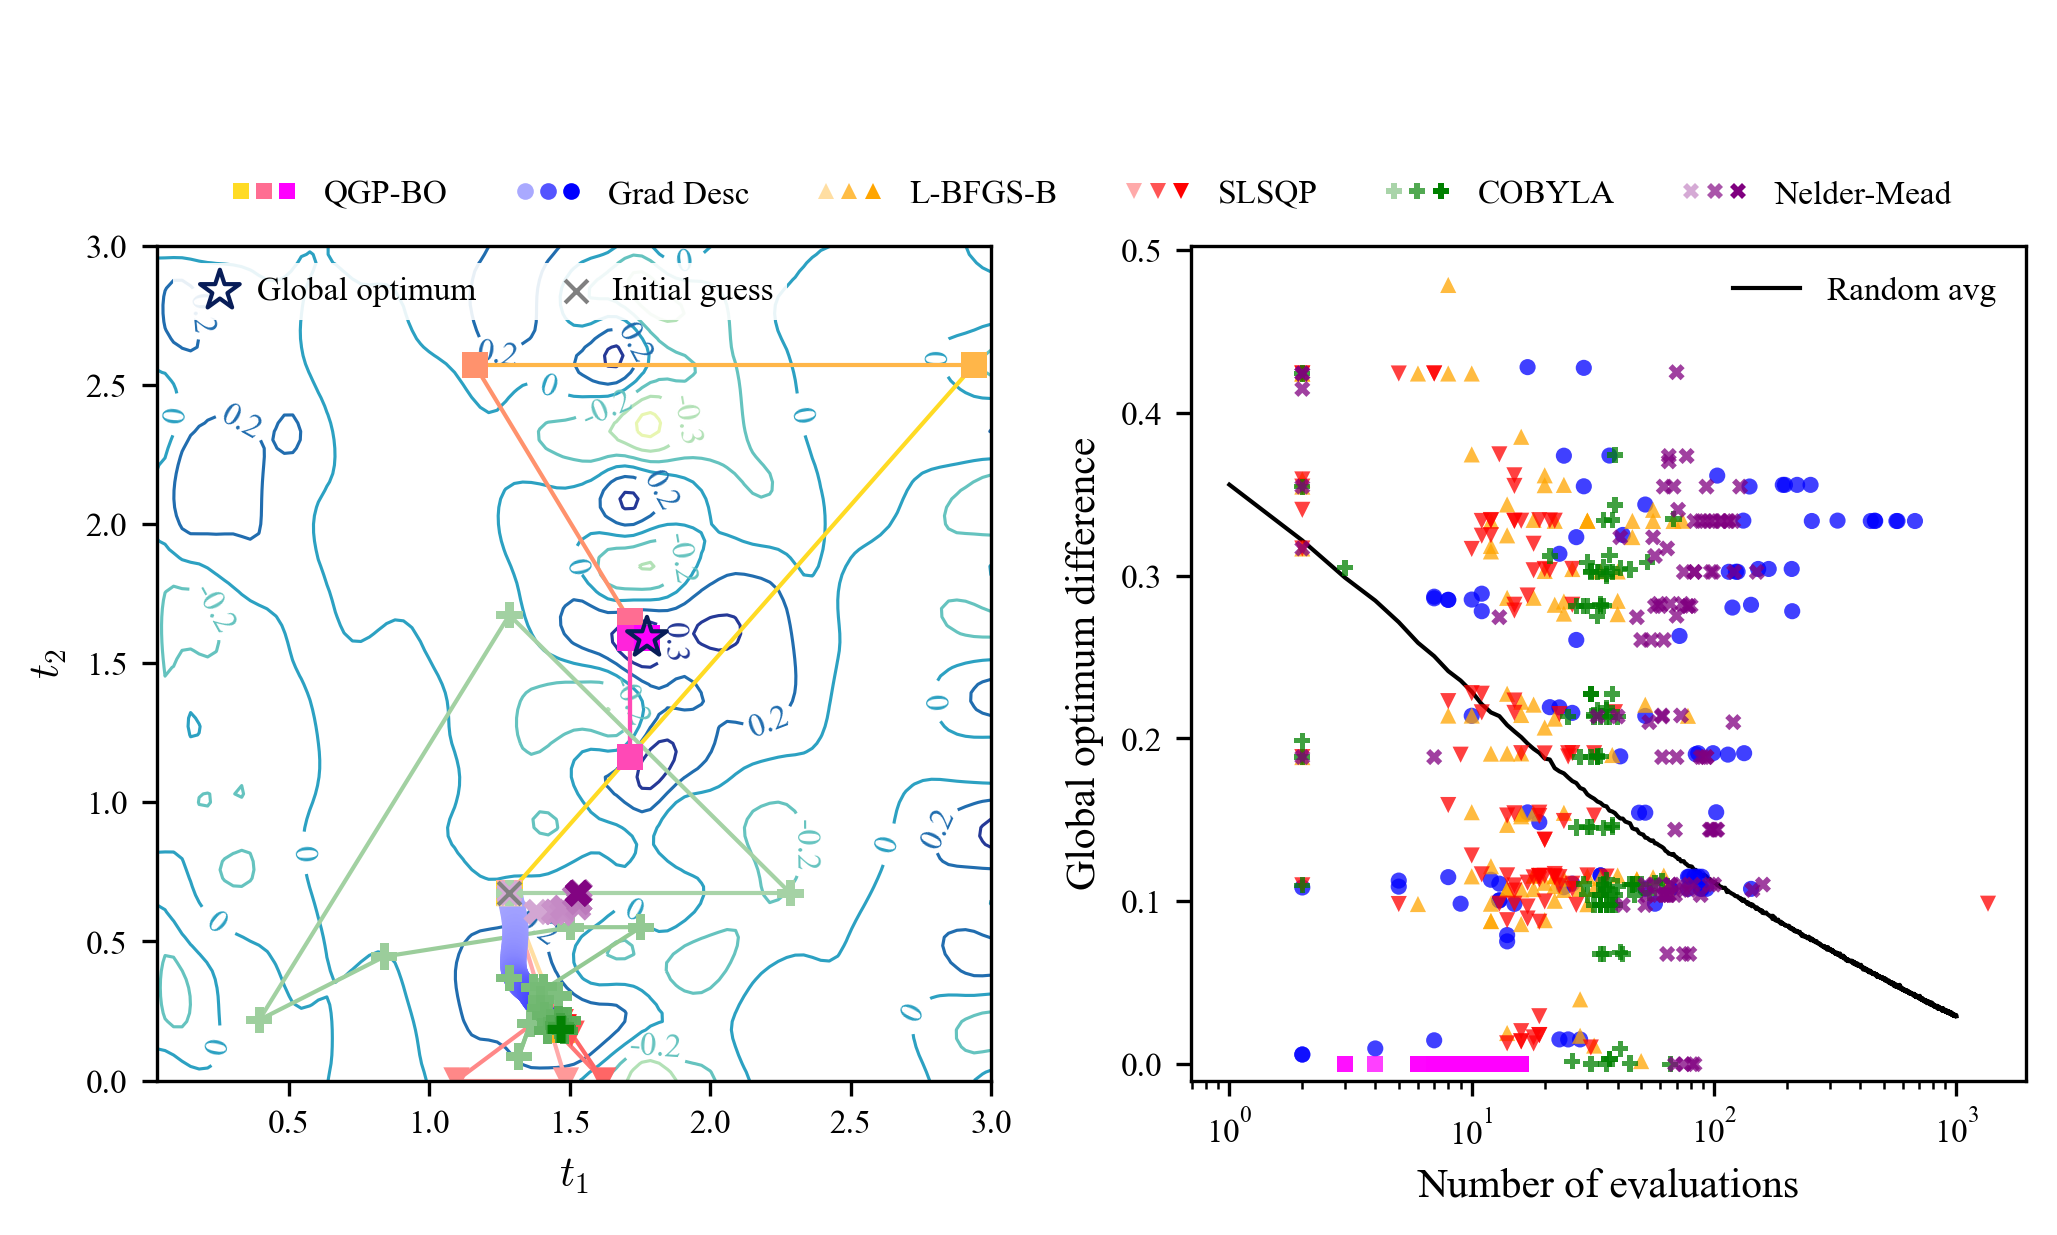

In [22]:
# Plotting
# textwidth is 6.92654 inches
fig = plt.figure(figsize=np.array((FULL_LINE_WIDTH_INCH, 4)), constrained_layout=True)

# Adjust gridspec: 2 rows (legend, plots), 2 columns (plot1, plot2)
gs = fig.add_gridspec(2, 2, height_ratios=[0.15, 1]) 

# Top row: Shared Legend
ax = fig.add_subplot(gs[0, :]) # Span across both columns
ax.axis('off')  # Hide the subplot axes
# We will populate this legend after extracting handles from the 2D plot below

# Left plot: 2D Contour
ax1 = fig.add_subplot(gs[1, 0])
_, legend_handles, legend_labels = plot_cost_contour_traj_2d(ax=ax1)
hl1 = ax1.get_legend_handles_labels()
if ax1.get_legend() is not None:
    ax1.get_legend().remove()
ax1.legend(*hl1, loc='upper left', handletextpad=0.1, ncols=2, framealpha=0.9, edgecolor='none')  # Pin it inside the plot to the top-left corner

# Populate the top legend now that we have the handles
ax.legend(ncol=6, loc="upper center",
          bbox_to_anchor=(0.5, -0.2),
          borderaxespad=0.0,
          borderpad = 0.0,
          frameon=False,
          handles=legend_handles[2:], labels=legend_labels[2:],
          handler_map={tuple: HandlerTuple(ndivide=None, pad=0.1)})

# Right plot: Evals vs Opt Diff
ax2 = fig.add_subplot(gs[1, 1])
plot_num_evals_vs_opt_diff(ax=ax2)
hl2 = ax2.get_legend_handles_labels()
if ax2.get_legend() is not None:
    ax2.get_legend().remove()
ax2.legend([hl2[0][-1]], [hl2[1][-1]], framealpha=0.9, edgecolor='none') # Internal legend for the evals plot

# --- (Removed the 3D axis scaling and positional fix blocks here) ---

# No tight layout!
if SAVE_FIGS:
    plt.savefig(f"../plots/BO_{n}q_bench.pdf", transparent=True, dpi=300)  # For paper
plt.show()